In [49]:
'''
Use EBHC and water correction to fit the simulation phantom to real data
'''

'\nUse EBHC and water correction to fit the simulation phantom to real data\n'

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize
import SimpleITK as sitk

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.fbp import additional_fbp_filter
from pcct_md_diffusion.utils import load_nist_attenuation, load_mixture_attenuation_from_composition_file
from pcct_md_diffusion.locations import base_input_dir

In [51]:
# load material attenuation data
ich = 1  # channel to analyze
min_kev = 30
max_kev = 120
step_kev = 5
kevs = np.arange(min_kev, max_kev + 1, step_kev)

df_att, dict_density = load_mixture_attenuation_from_composition_file(
    os.path.join(base_input_dir, 'omnitom_pcd/calibration/material_composition.csv'),
    os.path.join(base_input_dir, 'spectrum/NIST'),
    kevs=kevs,
    return_density=True
)

df_water = load_nist_attenuation(
    os.path.join(base_input_dir, 'spectrum/NIST/water.txt'),
    kevs=kevs
)

df_att['true_water'] = df_water['mu']
dict_density['true_water'] = 1.0

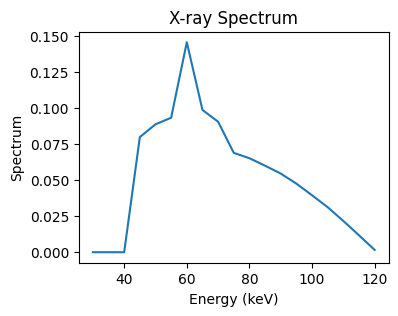

In [52]:
# load spectrum
# fist load with 1 kev step, then average to get the spectrum at the desired kevs

df_spec = pd.read_csv(os.path.join(base_input_dir, 'spectrum/xray/spektr_120kVp_Be2p0_Cu0p127_omnitom.csv'))

spectrum = [] 
for kev in kevs:
    idx = (df_spec['Energy_keV'] >= kev - (step_kev - 1) / 2) & (df_spec['Energy_keV'] <= kev + (step_kev - 1) / 2)
    spectrum.append(df_spec[idx]['Photons'].values.sum() / step_kev)
spectrum = np.array(spectrum)
# spectrum = spectrum * np.linspace(1, 0.1, len(spectrum))

if ich == 2:
    spectrum[kevs < 60] = 0
elif ich == 1:
    spectrum[kevs < 45] = 0

spectrum = spectrum / spectrum.sum()  # normalize

df_spec = pd.DataFrame({
    'energy': kevs,
    'spectrum': spectrum
})

plt.figure(figsize=(4, 3))
plt.plot(df_spec['energy'], df_spec['spectrum'])
plt.xlabel('Energy (keV)')
plt.ylabel('Spectrum')
plt.title('X-ray Spectrum')
plt.show()

Loading channel 0...
Loading channel 1...


Loading channel 2...


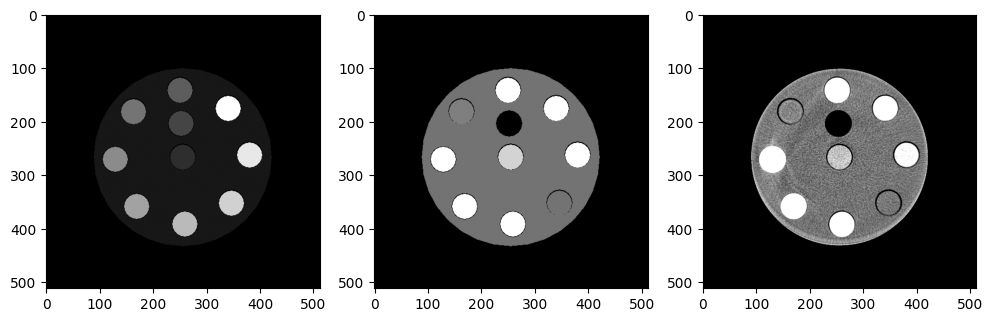

In [53]:
# load mask phantom
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
sitk_mask = sitk.ReadImage(os.path.join(calibration_dir, 'segmentation.seg.nrrd'))
dx, dy, dz = sitk_mask.GetSpacing()
mask = sitk.GetArrayFromImage(sitk_mask)[[0]]

# load phantom material labels
df_mask = pd.read_csv(os.path.join(calibration_dir, 'materials.csv'))

# compose a 60keV phantom
img_mono_60 = np.zeros_like(mask, dtype=np.float32)
for _, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    mu = df_att[df_att['energy'] == 60][material].values[0]
    img_mono_60[mask == label] = mu

# water attenuation at 60keV
mu_water_60 = df_att[df_att['energy'] == 60]['true_water'].values[0]

# load real phantom
imgs, _, _, _ = utils.load_image(calibration_dir)
imgs = imgs[:, [0], ...]

mu_waters = mu_waters = np.array([0.0196, 0.0192, 0.0186])
display_vmins = (-50 + 1000) / 1000 * mu_waters
display_vmaxs = (50 + 1000) / 1000 * mu_waters

imgs[imgs < -1000] = -1000
imgs = (imgs + 1000) / 1000 * mu_waters[:, None, None, None]
imgs = imgs.astype(np.float32)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 3, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

plt.subplot(1, 3, 3)
plt.imshow(imgs[ich, 0], 'gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [54]:
# geometry
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = imgs.shape[-1]
geo.ny = imgs.shape[-2]
geo.nz = imgs.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
leapct = utils.set_leapct_geometry(geo)
leapct.print_parameters()


======== CT Parallel-Beam Geometry ========
number of angles: 1440
number of detector elements (rows, cols): 1 x 878


True

angular range: 360.000000 degrees
detector pixel size: 5.656000 mm x 0.351570 mm
center detector pixel: 0.000000, 445.750000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 1
voxel size: 0.601562 mm x 0.601562 mm x 5.656000 mm
FOV: [-154.000000, 154.000000] x [-154.000000, 154.000000] x [-2.828000, 2.828000]

======== Processing Settings ========
GPU processing on devices 0, 1
GPU with least amount of memory: 34.782661 GB



Forward projecting...
Channel 0
Channel 1
Channel 2
Reconstructing...
Channel 0
Channel 1
Channel 2


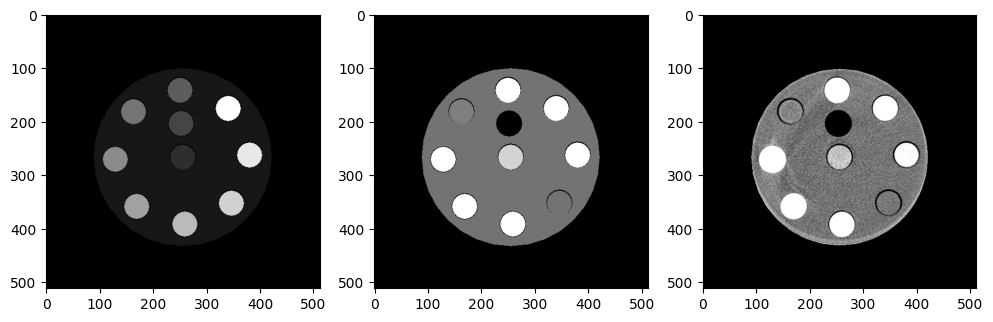

In [55]:
# cut off the area outside the phantom (foam) then do forward projection
phantom_mask = np.where(mask > 0, 1, 0)
# fill hole slice by slice
for i in range(phantom_mask.shape[0]):
    phantom_mask[i] = scipy.ndimage.binary_fill_holes(phantom_mask[i])

# set to air outside the phantom
imgs_masked = imgs.copy()
for ch in range(imgs.shape[0]):
    imgs_masked[ch] = np.where(phantom_mask > 0, imgs[ch], 0)

# forward projection
print('Forward projecting...', flush=True)
current_fp = leapct.allocate_projections()
prjs = []
for ch in range(imgs_masked.shape[0]):
    print('Channel', ch, flush=True)
    leapct.project(current_fp, imgs_masked[ch])
    prjs.append(np.copy(current_fp, 'C'))
prjs = np.array(prjs)

# reconstruction
print('Reconstructing...', flush=True)
fbps = []
for ch in range(prjs.shape[0]):
    print('Channel', ch, flush=True)
    current_fbp = leapct.FBP(prjs[ch])
    fbps.append(np.copy(current_fbp, 'C'))
fbps = np.array(fbps)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 3, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], 'gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [56]:
# forward project each material and make the ploychromatic projection
current_fp = leapct.allocate_projections()
prjs_materials = []
for i in range(len(df_mask)):
    label = df_mask.loc[i, 'Seg']
    material = df_mask.loc[i, 'Material']
    img_material = np.where(mask == label, 1, 0).astype(np.float32)
    _ = leapct.project(current_fp, img_material)
    prjs_materials.append(current_fp.copy())
prjs_materials = np.array(prjs_materials)

# the attenuation coefficient of each material at each energy
mus_materials = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    mus_materials.append(df_att[material].values)
mus_materials = np.array(mus_materials)

# compute the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
prjs_poly_simul = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)

In [57]:
def water_bhc_calibration_simul(att_water, spectrum, mu_water, max_thickness=300, poly_order=3):
    thicknesses = np.linspace(0, max_thickness, 100)
    attenuation = att_water * thicknesses[:, None]
    prjs = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1))
    prjs[prjs < 0] = 0

    # use polynomial fit without intercept
    A = np.vstack([prjs**i for i in range(1, poly_order + 1)]).T
    b = mu_water * thicknesses
    coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
    return coeffs


def apply_water_bhc(prjs, coeffs):
    return np.sum([coeffs[i] * prjs**(i + 1) for i in range(len(coeffs))], axis=0).astype(np.float32)

In [58]:
def get_roi_hu(img, mask, df_mask, mu_water):
    df_roi_hu = []
    for i, row in df_mask.iterrows():
        label = row['Seg']
        material = row['Material']
        roi_hu = img[mask == label].mean() / mu_water * 1000 - 1000
        df_roi_hu.append({
            'label': label,
            'material': material,
            'roi_hu': roi_hu
        })

    df_roi_hu = pd.DataFrame(df_roi_hu)
    return df_roi_hu

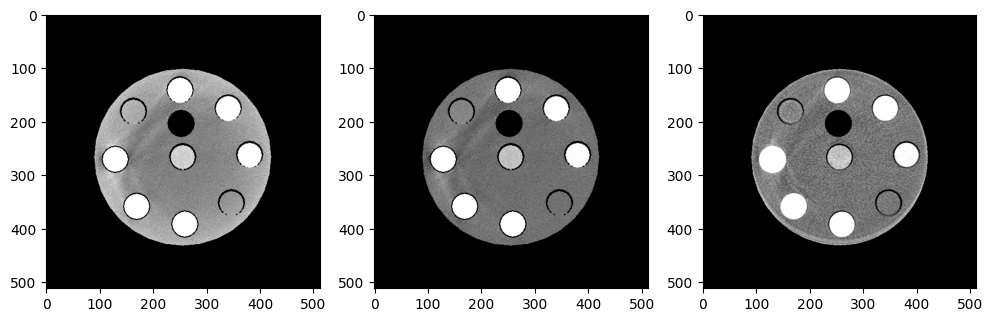

Material, Simul HU, Real HU
water_base, -9.03, -4.44
brain, 17.98, 23.39
adipose, -90.77, -75.61
iodine_10, 257.10, 251.84
true_water, -4.30, 0.40
calcium_300, 889.37, 959.70
calcium_100, 313.17, 295.08
calcium_50, 165.95, 141.62
water, -12.03, -5.81
iodine_2, 46.22, 48.22
iodine_5, 127.93, 126.24


In [59]:
bhc_water_coeffs_simul = water_bhc_calibration_simul(df_att['true_water'].values, spectrum, mu_waters[ich])
prjs_poly_simul_bhc_water = apply_water_bhc(prjs_poly_simul, bhc_water_coeffs_simul)
# prjs_poly_simul_bhc_water = additional_fbp_filter(prjs_poly_simul_bhc_water)
recon_poly_simul_bhc_water = leapct.FBP(prjs_poly_simul_bhc_water)
recon_poly_simul = leapct.FBP(prjs_poly_simul)

df_hu_simul = get_roi_hu(recon_poly_simul_bhc_water, mask, df_mask, mu_waters[ich])
df_hu_real = get_roi_hu(fbps[ich], mask, df_mask, mu_waters[ich])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_poly_simul[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

print('Material, Simul HU, Real HU')
for i, row in df_hu_simul.iterrows():
    label = row['label']
    material = row['material']
    hu_simul = row['roi_hu']
    hu_real = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    print(f'{material}, {hu_simul:.2f}, {hu_real:.2f}')

In [60]:
# recon_hu = (recon_poly_simul_bhc_water / mu_waters[ich] * 1000 - 1000).astype(np.int16)
# sitk_recon = sitk.GetImageFromArray(recon_hu)
# sitk_recon.SetSpacing(sitk_mask.GetSpacing())
# sitk_recon.SetOrigin(sitk_mask.GetOrigin())
# sitk_recon.SetDirection(sitk_mask.GetDirection())
# sitk.WriteImage(sitk_recon, os.path.join(calibration_dir, f'recon_fit_{ich}.nii.gz'))

Material, Simul HU with BHC, Simul HU without BHC, Real HU
water_base, -9.03, -9.20, -4.44
brain, 17.98, 19.82, 23.39
adipose, -90.77, -89.95, -75.61
iodine_10, 257.10, -12.19, 251.84
true_water, -4.30, -6.80, 0.40
calcium_300, 889.37, -14.28, 959.70
calcium_100, 313.17, -14.51, 295.08
calcium_50, 165.95, -14.25, 141.62
water, -12.03, -12.14, -5.81
iodine_2, 46.22, -12.20, 48.22
iodine_5, 127.93, -12.17, 126.24


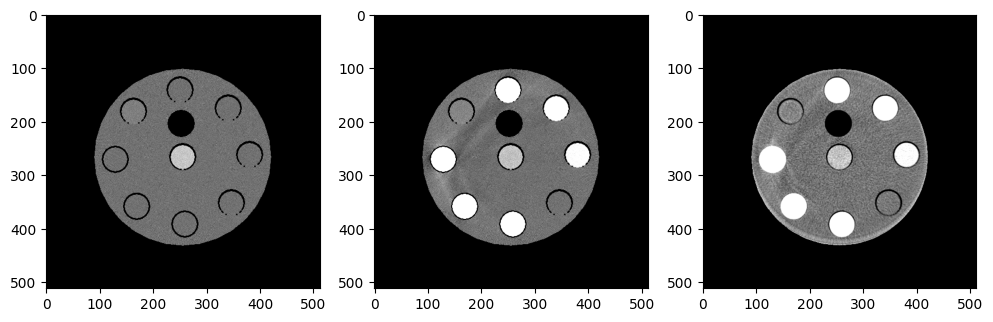

In [61]:
# simulate a BHC free image by replacing every none-water material with water
mus_materials_bhc_free = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    if any(water_keyword in material.lower() for water_keyword in ['water', 'adipose', 'brain']):
        mus_materials_bhc_free.append(df_att[material].values)
    else:
        mus_materials_bhc_free.append(df_att['water'].values)
mus_materials_bhc_free = np.array(mus_materials_bhc_free)

# compute the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials_bhc_free[:, None, None, None, :], axis=0)
prjs_poly_simul_2 = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)

prjs_poly_simul_2_bhc_water = apply_water_bhc(prjs_poly_simul_2, bhc_water_coeffs_simul)
recon_poly_simul_2_bhc_water = leapct.FBP(prjs_poly_simul_2_bhc_water)

df_hu_simul_2 = get_roi_hu(recon_poly_simul_2_bhc_water, mask, df_mask, mu_waters[ich])
print('Material, Simul HU with BHC, Simul HU without BHC, Real HU')
for i, row in df_hu_simul.iterrows():
    label = row['label']
    material = row['material']
    hu_simul_bhc = row['roi_hu']
    hu_simul_no_bhc = df_hu_simul_2[df_hu_simul_2['label'] == label]['roi_hu'].values[0]
    hu_real = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    print(f'{material}, {hu_simul_bhc:.2f}, {hu_simul_no_bhc:.2f}, {hu_real:.2f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_poly_simul_2_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

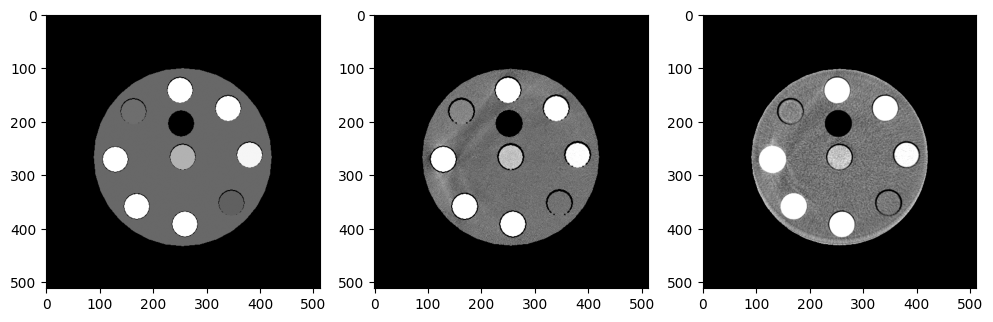

In [62]:
# build a target phantom for ebhc
# use the mean value from df_hu_simul_2 if it is one of water, adipose, or brain
# otherwise use the mean value from df_hu_simul
# convert the hu to mu

target_phantom = np.zeros_like(mask, dtype=np.float32)
for i, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    if any(water_keyword in material.lower() for water_keyword in ['water', 'adipose', 'brain']):
        hu = df_hu_simul_2[df_hu_simul_2['label'] == label]['roi_hu'].values[0]
    else:
        hu = df_hu_simul[df_hu_simul['label'] == label]['roi_hu'].values[0]
    mu = (hu + 1000) / 1000 * mu_waters[ich]
    target_phantom[mask == label] = mu

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(target_phantom[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

EBHC coefficients: [-0.10327811  0.01168704  0.04356456]


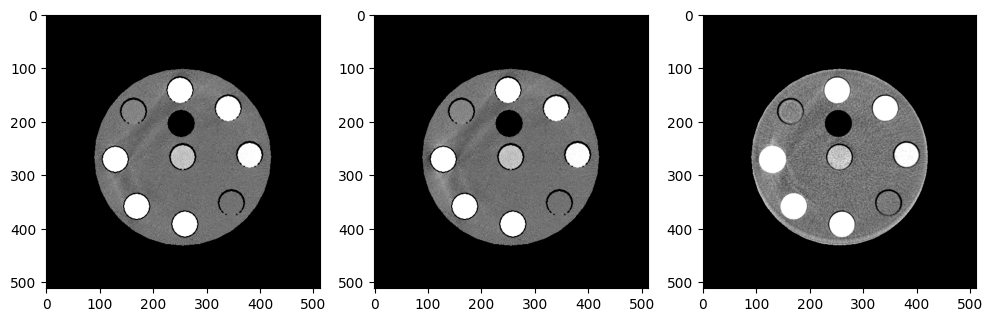

Material, EBHC Simul HU, Real HU
water_base, -9.03, -4.44
brain, 18.45, 23.39
adipose, -90.61, -75.61
iodine_10, 257.36, 251.84
true_water, -4.96, 0.40
calcium_300, 845.07, 959.70
calcium_100, 313.04, 295.08
calcium_50, 166.08, 141.62
water, -11.93, -5.81
iodine_2, 46.37, 48.22
iodine_5, 128.08, 126.24


In [63]:
# fit the simulated projection to the real data
# first find the high-density components in the reconstruction

threshold = 1400 / 1000 * mu_waters[ich]  # 300 HU in terms of attenuation coefficient
bone_image = np.where(recon_poly_simul_bhc_water > threshold, recon_poly_simul_bhc_water, 0)
prjs_bone = leapct.allocate_projections()
_ = leapct.project(prjs_bone, bone_image)

prjs_real = prjs[ich]
prjs_mask = np.where(prjs_bone > 0)

# fit the bone projection to the projection from the target phantom
prjs_target = leapct.allocate_projections()
_ = leapct.project(prjs_target, target_phantom)

p_t = prjs_target[prjs_mask]
p_b = prjs_bone[prjs_mask]
p_p = prjs_poly_simul_bhc_water[prjs_mask]

A = np.vstack([p_b, p_b * p_p, p_b**2]).T
b = p_t - p_p
coeffs_ebhc = np.linalg.lstsq(A, b, rcond=None)[0]
print('EBHC coefficients:', coeffs_ebhc)

# EBHC
prjs_ebhc = prjs_poly_simul_bhc_water + coeffs_ebhc[0] * prjs_bone + coeffs_ebhc[1] * prjs_bone * prjs_poly_simul_bhc_water + coeffs_ebhc[2] * prjs_bone**2
recon_ebhc = leapct.FBP(prjs_ebhc)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_ebhc[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

# roi hu
df_hu_ebhc = get_roi_hu(recon_ebhc, mask, df_mask, mu_waters[ich])
print('Material, EBHC Simul HU, Real HU')
for i, row in df_hu_simul.iterrows():
    label = row['label']
    material = row['material']
    hu_ebhc = df_hu_ebhc[df_hu_ebhc['label'] == label]['roi_hu'].values[0]
    hu_real = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    print(f'{material}, {hu_ebhc:.2f}, {hu_real:.2f}')

In [64]:
recon_hu = (recon_ebhc / mu_waters[ich] * 1000 - 1000).astype(np.int16)
sitk_recon = sitk.GetImageFromArray(recon_hu)
sitk_recon.SetSpacing(sitk_mask.GetSpacing())
sitk_recon.SetOrigin(sitk_mask.GetOrigin())
sitk_recon.SetDirection(sitk_mask.GetDirection())
sitk.WriteImage(sitk_recon, os.path.join(calibration_dir, f'recon_ebhc_{ich}.nii.gz'))